# Bet Sizing With The Kelly Criterion

Whenever engaging in a game of chance, the goal, more so than enjoyment, is to win. Typically, we bet on the outcome of these games, risking money with hopes of being rewarded. But, we know that in games like roulette, we may win a few games in a row, yet we are bound to lose. If we continuously wager our entire bankroll, it is certain to go to zero. So, with this in mind, how much should we bet on each turn?

We can think of this in terms of Expected Value ($EV$). Let $P(x)$ denote the probability of an outcome, and $G(x)$ denote the gains of an outcome. For a binary game (ex. Win-Lose game), the $EV$ is given by: $$EV = P(win)G(win) + P(lose)G(lose)$$

The first step in utilizing the Kelly Criterion is understanding when we should even partake in a game in the first place. The Kelly Criterion states:

- If the $EV$ is 0 (ex. coin flip or any zero-sum game) we have no real edge, and we should not engage in the game.
- If the $EV$ is positive, we have an edge, and we should bet on this game according to the bet sizing indicated by the Kelly Criterion
- Interestingly, if the $EV$ is negative, we should not play the game; we should offer it. Think being the casino.

Next, we must calculate the optimal bet sizing, in terms of a percentage of total bankroll. Let:

- $p$ = probability of winning,
- $q$ = $(1-p)$ = probability of losing,
- $s$ = fraction of bet that is lost upon negative outcome,
- $t$ = fraction of bet that is gained upon positive outcome, and
- $f$ = fraction of bankroll to wager.

Then, the optimal bet sizing is given by $$f = \frac{p}{s} - \frac{q}{t}$$

In the animation below, we take advantage of a positive $EV$ game, and employ the Kelly bet. In this example, $p = 0.6$, $t = 1.5$, and $s = 1$. While risk-averse players will bet $\frac{f}{2}$ or $\frac{f}{4}$, we will bet the full Kelly bet, $f$.

In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.widgets import Slider, Button
from IPython.display import HTML

# initialize variables
games = 100
lst_games = np.arange(games+1)

bankroll = 1
path = [bankroll]

p = 0.6
t = 1.5
s = 1

# kelly bet eqn
f = (p / s) - ( (1-p) / t )

# simulate games
for _ in range(games):
    bet = bankroll * f
    outcome = np.random.choice([t, -s], p=[p, 1-p])

    bankroll += outcome * bet
    path.append(round(bankroll, 2))

#plot
fig, ax = plt.subplots()
plt.yscale("log", base=10)
ax.set_ylim(min(path) * 0.5 , max(path) * 2)
ax.set_xlim(0, games)

# initialize line using list unpacking
[line] = ax.plot([], [], lw=2)

# update function
def animate_frame(frame):
    # slice data up to current frame
    x = lst_games[:frame+1]
    y = path[:frame+1]

    line.set_data(x, y) # update line
    return [line]

# create animation
ani = animation.FuncAnimation(
    fig=fig,
    func=animate_frame,
    frames=games+1,
    interval=75 ,
    blit=True,
)
plt.close()
HTML(ani.to_jshtml(default_mode='once')) # show animation

By the semi-log plot, we can see that our bankroll grows exponentially. But how does this strategy actually work?

The naive approach involves maximizing the Expected Value for each bet, but this strategy will quickly prove to be futile. Imagine betting on a weighted coint, where $p_{heads} = 0.6$ and $p_{tails} = 0.4$. Each time we land on heads, we double our money, but when we land on tails, we lose it all. Let us plot the $EV$ as a function of bet sizing.

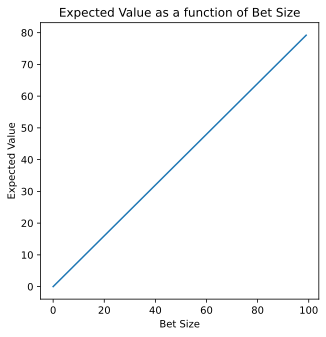

In [6]:
%config InlineBackend.figure_format = 'svg'
import numpy as np
import matplotlib.pyplot as plt

plt.close("all")

# initialize variables
p_heads = 0.6
p_tails = 0.4
t = 2
s = 1

ev = p_heads*t - p_tails*s

x = np.array(range(100))
y = x * ev

# plot
plt.figure(figsize=(5,5))
plt.plot(x, y)

plt.title("Expected Value as a function of Bet Size")
plt.xlabel("Bet Size")
plt.ylabel("Expected Value")
plt.show()

As modeled by the somewhat boring plot, the $EV$ scales linearly with bet size. So why not go all in on each bet? As you may have guessed, betting our entire backroll on each flip will cause us to go broke with 100% certainty, since, in the long-term, we our bound to land on tails. This is why we use the Kelly bet, which takes a different approach, one that maximized the long-term expected geometric growth rate.

A series of bets on a positive $EV$ game can be modeled by an exponential function, since our bankroll compounds as we bet more money. Let $f$ denote a single bet, as a fraction of our 1 dollar (unit) bankroll. The return for a positive outcome is $(1+tf)$ and the loss for a negative outcome is $(1-sf)$. Take a moment to convince yourself of this. Our geometric growth rate $R$, the cumulative product of wins and losses in proportion to their probabilities, is given by $$R = (1+tf)^p (1-sf)^q$$ where $q=(1-p)$. To maximize our growth rate, we will take the derivative and set it equal to 0. Before this, we will take the logarithm of both sides, to convert the products into sums. $$log(R) = p log(1+tf) + qlog(1-sf)$$ Now we take the derivative of $log(R)$ as a function of $f$. $$\left. \frac{d(log(R))}{df}\right|_{f=f_{max}} = \frac{pt}{1-tf} - \frac{qs}{1-sf} = 0$$ Solving for $f_{max}$ gives the original $$f_{max} = \frac{p}{s} - \frac{q}{t}$$

By our intuition, we would assume that as our probability of winning increases, our bet size should increase. Also, we would assume that as our gain per win increases, our bet size should increase. Through some analysis, we see that the Kelly bet equation follows these assumptions. For fun, lets visualize these results on a 3D graph

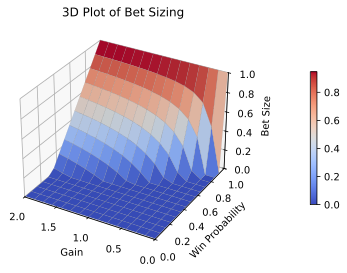

In [10]:

import numpy as np
import matplotlib.pyplot as plt

plt.close("all")

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# data 
prob = np.linspace(0.01, 1, num=15)
gain = np.linspace(0.01, 2, num=15)
loss = 1

prob, gain = np.meshgrid(prob, gain)

kelly_bet = (prob/loss) - ( (1-prob)/gain )
kelly_bet[ kelly_bet < 0] = 0

# plot
surface =  ax.plot_surface(gain, 
                           prob, 
                           kelly_bet,
                           linewidth=0,
                           cmap="coolwarm",  
                           antialiased=False,
                          )
lines =  ax.plot_surface(gain, 
                         prob, 
                         kelly_bet, 
                         rcount=15,
                         ccount=15,
                         edgecolor="grey",
                         linewidth=0.1,
                         alpha=0.1 # translucent
                        )
                        
fig.colorbar(surface, shrink=0.5, pad=0.2)

plt.title("3D Plot of Bet Sizing")
ax.set_xlim(0, 2)
ax.invert_xaxis()
ax.set_xlabel("Gain")
ax.set_ylim(0, 1)
ax.set_ylabel("Win Probability")
ax.set_zlim(0, 1)
ax.set_zlabel("Bet Size")

plt.show()